# Prophet Standalone Model
Using Prophet for time series forecasting with external regressors

### 1. Load and Prepare Data

In [25]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
import warnings
warnings.filterwarnings('ignore')

# ========== CONFIGURATION: CHANGE THESE VALUES ==========
# Choose which dataset to use: 1, 2, or 3
DATASET_VERSION = 2  # Change this to 1 or 3 to test other feature sets

# Define features for each dataset
FEATURE_CONFIGS = {
    1: {
        'file': '../data/final_features_1.csv',
        'features': [
            "platt_apag_mom_pct",
            "platt_crude_mom_pct",
            "temp_avg",
            "precip_avg",
            "threshold_temp_days",
            "threshold_rainy_days",
            "possible_working_days",
            "avg_weight"
        ],
        'name': 'final_features_1.csv'
    },
    2: {
        'file': '../data/final_features_2.csv',
        'features': [
            "season_sin",
            "season_cos",
            "temp_avg",
            "precip_avg",
            "possible_working_days",
            "avg_weight",
            "ap_price_weight",
            "crude_price_weight"
        ],
        'name': 'final_features_2.csv'
    },
}
# ========================================================

# Load selected dataset
config = FEATURE_CONFIGS[DATASET_VERSION]
df = pd.read_csv(config['file'])
df["ds"] = pd.to_datetime(df["date"], format="%Y%m") + pd.offsets.MonthEnd(0)
df = df.rename(columns={"demand": "y"})
feature_cols = config['features']
dataset_name = config['name']

# Ensure numeric types
for col in feature_cols:
    df[col] = df[col].astype(float)

# Train/validation split (last 32 months for validation)
cutoff = df["ds"].max() - pd.DateOffset(months=32)
df_train = df[["ds", "y"] + feature_cols].copy()
df_train = df_train[df_train["ds"] <= cutoff]
df_valid = df[["ds", "y"] + feature_cols].copy()
df_valid = df_valid[df_valid["ds"] > cutoff]

print(f"Using dataset: {dataset_name}")
print(f"Number of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")
print(f"\nTraining set: {len(df_train)} samples ({df_train['ds'].min()} to {df_train['ds'].max()})")
print(f"Validation set: {len(df_valid)} samples ({df_valid['ds'].min()} to {df_valid['ds'].max()})")

Using dataset: final_features_2.csv
Number of features: 8
Features: ['season_sin', 'season_cos', 'temp_avg', 'precip_avg', 'possible_working_days', 'avg_weight', 'ap_price_weight', 'crude_price_weight']

Training set: 264 samples (2001-01-31 00:00:00 to 2022-12-31 00:00:00)
Validation set: 32 samples (2023-01-31 00:00:00 to 2025-08-31 00:00:00)


### 2. Hyperparameter Tuning with Cross-Validation

Prophet has several key hyperparameters to tune:
- **changepoint_prior_scale**: Controls trend flexibility (higher = more flexible)
- **seasonality_prior_scale**: Controls seasonality strength (higher = stronger seasonal patterns)
- **seasonality_mode**: 'additive' or 'multiplicative'
- **changepoint_range**: Proportion of data where changepoints can occur
- **n_changepoints**: Number of potential changepoints

We'll use Prophet's built-in time series cross-validation to find the best parameters.

In [26]:
from prophet.diagnostics import cross_validation, performance_metrics
from itertools import product
import time

# ========== HYPERPARAMETER GRID ==========
# Adjust these ranges based on your needs
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'seasonality_mode': ['multiplicative'],
    'changepoint_range': [0.8, 0.9],
}
# =========================================

# Generate all combinations
all_params = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]
print(f"Testing {len(all_params)} parameter combinations...")
print(f"This may take several minutes...\n")

# Store results
cv_results = []

start_time = time.time()

for i, params in enumerate(all_params, 1):
    try:
        # Initialize model with current parameters
        m = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            **params
        )

        # Add regressors
        for feature in feature_cols:
            m.add_regressor(feature)

        # Fit on training data
        m.fit(df_train)

        # Cross-validation: 3 splits, 6-month horizon
        # initial: minimum training size, period: spacing between cutoffs, horizon: forecast length
        # Cross-validation setup for 24 years of data
        df_cv = cross_validation(
            m,
            initial='3650 days',  # Start testing after 10 years of training (2001-2010)
            period='365 days',    # Test once per year (instead of every 3 months)
            horizon='180 days',   # Forecast 6 months ahead
            parallel="processes"
        )

        # Calculate metrics
        df_metrics = performance_metrics(df_cv)

        # Store results
        cv_results.append({
            'params': params,
            'rmse': df_metrics['rmse'].mean(),
            'mae': df_metrics['mae'].mean(),
            'mape': df_metrics['mape'].mean(),
        })

        if i % 5 == 0:
            elapsed = time.time() - start_time
            print(f"Completed {i}/{len(all_params)} combinations ({elapsed:.1f}s)")

    except Exception as e:
        print(f"Error with params {params}: {str(e)}")
        continue

print(f"\n✅ Hyperparameter tuning complete!")
print(f"Total time: {(time.time() - start_time)/60:.1f} minutes")

# Convert to DataFrame and sort by RMSE
cv_df = pd.DataFrame(cv_results)
cv_df = cv_df.sort_values('rmse')

print("\n" + "="*70)
print("TOP 5 PARAMETER COMBINATIONS (by RMSE):")
print("="*70)
for idx, row in cv_df.head(5).iterrows():
    print(f"\nRank {cv_df.index.get_loc(idx) + 1}:")
    print(f"  RMSE: {row['rmse']:,.1f}")
    print(f"  MAE:  {row['mae']:,.1f}")
    print(f"  MAPE: {row['mape']:.2f}%")
    print(f"  Parameters: {row['params']}")

# Get best parameters
best_params = cv_df.iloc[0]['params']
print("\n" + "="*70)
print("BEST PARAMETERS (selected for final model):")
print("="*70)
for key, value in best_params.items():
    print(f"  {key}: {value}")

Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
11:28:32 - cmdstanpy - INFO - Chain [1] start processing
Importing plotly failed. Interactive plots will not work.
11:28:32 - cmdstanpy - INFO - Chain [1] done processing
11:28:32 - cmdstanpy - INFO - Chain [1] start processing
11:28:32 - cmdstanpy - INFO - Chain [1] start processing
11:28:32 - cmdstanpy - INFO - Chain [1] start processing
11:28:32 - cmdstanpy - INFO - Chain [1] start processing
11:28:32 - cmdstanpy - INFO - Chain [1] start processing
11:28:32 - cmdstanpy -

Completed 5/32 combinations (5.1s)


Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
11:28:34 - cmdstanpy - INFO - Chain [1] start processing
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
11:28:34 - cmdstanpy - INFO - Chain [1] done processing
11:28:34 - cmdstanpy - INFO - Chain [1] start processing
11:28:34 - cmdstanpy - INFO - Chain [1] start processing
11:28:34 - cmdstanpy - INFO - Chain [1] start processing
11:28:34 - cmdstanpy - INFO - Chain [1] start processing
11:28:34 - cmdstanpy - INFO - Chain [1] start processing
11:28:34 - cmdstanpy - INFO - Chain [1] start processing
11:28:34 - cmdstanpy - 

Completed 10/32 combinations (10.8s)


Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
11:28:39 - cmdstanpy - INFO - Chain [1] start processing
Importing plotly failed. Interactive plots will not work.
11:28:39 - cmdstanpy - INFO - Chain [1] start processing
Importing plotly failed. Interactive plots will not work.
11:28:39 - cmdstanpy - INFO - Chain [1] start processing
Importing plotly failed. Interactive plots will not work.
11:28:40 - cmdstanpy - INFO - Chain [1] start processing
11:28:40 - cmdstanpy - INFO - Chain [1] done processing
11:28:40 - cmdstanpy - INFO - Chain [1] done processing
Importing plotly failed. Interactive plots will not work.
11:28:40 - cmdstanpy - INFO - Chain [1] start processing
11:28:40 - cmdstanpy - 

...

Completed 25/32 combinations (25.9s)


Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
11:28:55 - cmdstanpy - INFO - Chain [1] start processing
Importing plotly failed. Interactive plots will not work.
11:28:55 - cmdstanpy - INFO - Chain [1] start processing
Importing plotly failed. Interactive plots will not work.
11:28:55 - cmdstanpy - INFO - Chain [1] done processing
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
11:28:55 - cmdstanpy - INFO - Chain [1] start processing
11:28:55 - cmdstanpy - INFO - Chain [1] start processing
11:28:55 - cmdstanpy - INFO - Chain [1] start processing
11:28:55 - cmdstanpy - INFO - Chain [1] done processing
Importing plotly failed. Interactive plots will not work.
11:28:55 - cmdstanpy - 

Completed 30/32 combinations (31.0s)


Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
11:29:00 - cmdstanpy - INFO - Chain [1] start processing
11:29:00 - cmdstanpy - INFO - Chain [1] start processing
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
11:29:00 - cmdstanpy - INFO - Chain [1] start processing
11:29:00 - cmdstanpy - INFO - Chain [1] done processing
11:29:00 - cmdstanpy - INFO - Chain [1] start processing
Importing plotly failed. Interactive plots will not work.
11:29:00 - cmdstanpy - INFO - Chain [1] start processing
11:29:00 - cmdstanpy - INFO - Chain [1] start processing
11:29:00 - cmdstanpy - INFO - Chain [1] done processing
Importing plotly failed.


✅ Hyperparameter tuning complete!
Total time: 0.6 minutes

TOP 5 PARAMETER COMBINATIONS (by RMSE):

Rank 1:
  RMSE: 25,311.2
  MAE:  19,531.5
  MAPE: 0.15%
  Parameters: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 0.01, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.9}

Rank 2:
  RMSE: 25,769.9
  MAE:  20,654.1
  MAPE: 0.16%
  Parameters: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.9}

Rank 3:
  RMSE: 26,055.7
  MAE:  21,289.7
  MAPE: 0.16%
  Parameters: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.9}

Rank 4:
  RMSE: 26,066.3
  MAE:  21,270.7
  MAPE: 0.16%
  Parameters: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.9}

Rank 5:
  RMSE: 26,287.9
  MAE:  21,573.7
  MAPE: 0.16%
  Parameters: {'changepoint_prior_scale':

### 3. Train Final Model with Best Parameters

In [27]:
# Initialize Prophet model with best parameters
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    **best_params
)

# Add all features as external regressors
for feature in feature_cols:
    model.add_regressor(feature)

print("Training Prophet model with best parameters...")
print(f"Features used as regressors: {len(feature_cols)}")

# Fit model
model.fit(df_train)

print("\nModel training complete!")

11:29:01 - cmdstanpy - INFO - Chain [1] start processing
11:29:01 - cmdstanpy - INFO - Chain [1] done processing


Training Prophet model with best parameters...
Features used as regressors: 8

Model training complete!


### 4. Make Predictions

In [28]:
# Make predictions
train_forecast = model.predict(df_train)
valid_forecast = model.predict(df_valid)

train_pred = train_forecast['yhat'].values
valid_pred = valid_forecast['yhat'].values

print(f"Predictions generated: {len(train_pred)} train, {len(valid_pred)} valid")

Predictions generated: 264 train, 32 valid


### 5. Evaluate and Save Results

In [29]:
def calculate_metrics(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmspe = np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2)) * 100
    
    print(f"\n{label} Metrics:")
    print(f"  RMSE:  {rmse:,.1f}")
    print(f"  MAE:   {mae:,.1f}")
    print(f"  MAPE:  {mape:.2f}%")
    print(f"  RMSPE: {rmspe:.2f}%")
    
    return {'rmse': rmse, 'mae': mae, 'mape': mape, 'rmspe': rmspe}

train_metrics = calculate_metrics(df_train['y'].values, train_pred, "Training")
valid_metrics = calculate_metrics(df_valid['y'].values, valid_pred, "Validation")

# Save results
import json
from datetime import datetime
import glob
import re

prophet_params = {
    'yearly_seasonality': True,
    'seasonality_mode': best_params['seasonality_mode'],
    'changepoint_prior_scale': best_params['changepoint_prior_scale'],
    'seasonality_prior_scale': best_params['seasonality_prior_scale'],
    'changepoint_range': best_params['changepoint_range'],
    'num_regressors': len(feature_cols)
}

existing_files = glob.glob(f"../results/prophet_feature{DATASET_VERSION}_results_*.json")
params_exist = False
existing_run = None

for file in existing_files:
    try:
        with open(file, 'r') as f:
            existing_data = json.load(f)
            ep = existing_data.get('model_parameters', {})
            if (ep.get('seasonality_mode') == prophet_params['seasonality_mode'] and
                ep.get('changepoint_prior_scale') == prophet_params['changepoint_prior_scale'] and
                ep.get('seasonality_prior_scale') == prophet_params['seasonality_prior_scale'] and
                ep.get('changepoint_range') == prophet_params['changepoint_range']):
                params_exist = True
                existing_run = file
                break
    except:
        continue

if params_exist:
    print("\n" + "="*60)
    print("⚠️  RESULTS NOT SAVED - Parameters already exist")
    print(f"File: {existing_run}")
    print("="*60)
else:
    run_numbers = []
    for file in existing_files:
        match = re.search(rf'prophet_feature{DATASET_VERSION}_results_(\d+)\.json', file)
        if match:
            run_numbers.append(int(match.group(1)))
    
    next_run = max(run_numbers) + 1 if run_numbers else 1
    
    results = {
        "model_name": f"Prophet Standalone - {dataset_name}",
        "model_type": "Prophet",
        "run_number": next_run,
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "dataset": dataset_name,
        "features": feature_cols,
        "num_features": len(feature_cols),
        "train_samples": len(df_train),
        "valid_samples": len(df_valid),
        "model_parameters": prophet_params,
        "metrics": {
            "training": {
                "rmse": float(train_metrics['rmse']),
                "mae": float(train_metrics['mae']),
                "mape": float(train_metrics['mape']),
                "rmspe": float(train_metrics['rmspe'])
            },
            "validation": {
                "rmse": float(valid_metrics['rmse']),
                "mae": float(valid_metrics['mae']),
                "mape": float(valid_metrics['mape']),
                "rmspe": float(valid_metrics['rmspe'])
            }
        }
    }
    
    result_path = f"../results/prophet_feature{DATASET_VERSION}_results_{next_run}.json"
    with open(result_path, 'w') as f:
        json.dump(results, f, indent=2)
    
    print("\n" + "="*60)
    print(f"✅ Results saved to: {result_path}")
    print(f"Run number: {next_run}")
    print("="*60)


Training Metrics:
  RMSE:  20,888.8
  MAE:   16,317.9
  MAPE:  14.34%
  RMSPE: 23.21%

Validation Metrics:
  RMSE:  28,376.2
  MAE:   22,689.7
  MAPE:  18.65%
  RMSPE: 21.68%

✅ Results saved to: ../results/prophet_feature2_results_1.json
Run number: 1


### 6. Visualize Predictions

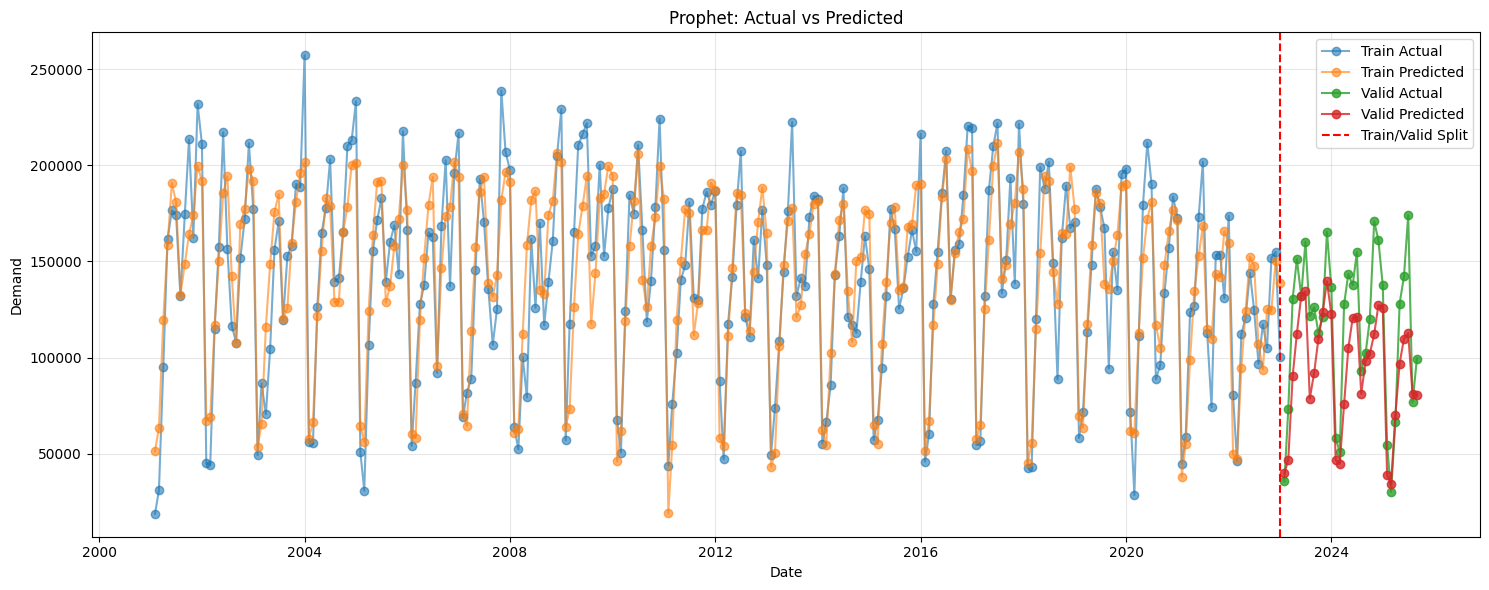

In [30]:
import matplotlib.pyplot as plt

viz_train = df_train.copy()
viz_train['prediction'] = train_pred
viz_valid = df_valid.copy()
viz_valid['prediction'] = valid_pred

plt.figure(figsize=(15, 6))
plt.plot(viz_train['ds'], viz_train['y'], 'o-', label='Train Actual', alpha=0.6)
plt.plot(viz_train['ds'], viz_train['prediction'], 'o-', label='Train Predicted', alpha=0.6)
plt.plot(viz_valid['ds'], viz_valid['y'], 'o-', label='Valid Actual', alpha=0.8)
plt.plot(viz_valid['ds'], viz_valid['prediction'], 'o-', label='Valid Predicted', alpha=0.8)
plt.axvline(x=cutoff, color='red', linestyle='--', label='Train/Valid Split')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.title('Prophet: Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# ========== MANUAL PARAMETER OVERRIDE ==========
# Set ENABLE_MANUAL_OVERRIDE = True to test custom parameters
ENABLE_MANUAL_OVERRIDE = False

manual_params = {
    'changepoint_prior_scale': 0.05,      # Increase if missing trend changes
    'seasonality_prior_scale': 10.0,      # Increase for stronger seasonality
    'seasonality_mode': 'multiplicative', # 'additive' or 'multiplicative'
    'changepoint_range': 0.8,             # Proportion of data for changepoints
}
# ================================================

if ENABLE_MANUAL_OVERRIDE:
    print("🔧 MANUAL OVERRIDE ENABLED - Training with custom parameters...")
    print(f"Custom parameters: {manual_params}\n")
    
    # Train with manual parameters
    model_manual = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        **manual_params
    )
    
    for feature in feature_cols:
        model_manual.add_regressor(feature)
    
    model_manual.fit(df_train)
    
    # Make predictions
    train_forecast_manual = model_manual.predict(df_train)
    valid_forecast_manual = model_manual.predict(df_valid)
    
    train_pred_manual = train_forecast_manual['yhat'].values
    valid_pred_manual = valid_forecast_manual['yhat'].values
    
    # Evaluate
    train_metrics_manual = calculate_metrics(df_train['y'].values, train_pred_manual, "Training (Manual)")
    valid_metrics_manual = calculate_metrics(df_valid['y'].values, valid_pred_manual, "Validation (Manual)")
    
    # Compare with best params
    print("\n" + "="*70)
    print("COMPARISON: Manual vs Best Parameters")
    print("="*70)
    print(f"\nValidation RMSE:")
    print(f"  Best Params (Auto):  {valid_metrics['rmse']:,.1f}")
    print(f"  Manual Override:     {valid_metrics_manual['rmse']:,.1f}")
    print(f"  Difference:          {valid_metrics_manual['rmse'] - valid_metrics['rmse']:+,.1f}")
    
    print(f"\nValidation MAPE:")
    print(f"  Best Params (Auto):  {valid_metrics['mape']:.2f}%")
    print(f"  Manual Override:     {valid_metrics_manual['mape']:.2f}%")
    print(f"  Difference:          {valid_metrics_manual['mape'] - valid_metrics['mape']:+.2f}%")
    
    # Visualize comparison
    plt.figure(figsize=(15, 6))
    plt.plot(viz_valid['ds'], viz_valid['y'], 'o-', label='Actual', alpha=0.8, color='black')
    plt.plot(viz_valid['ds'], valid_pred, 'o-', label='Auto Best Params', alpha=0.7)
    plt.plot(viz_valid['ds'], valid_pred_manual, 'o-', label='Manual Override', alpha=0.7)
    plt.xlabel('Date')
    plt.ylabel('Demand')
    plt.title('Validation: Manual vs Auto Parameters')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n💡 If manual parameters perform better, update best_params and re-run Section 5 to save results")
else:
    print("ℹ️  Manual override disabled. Set ENABLE_MANUAL_OVERRIDE = True to test custom parameters")

ℹ️  Manual override disabled. Set ENABLE_MANUAL_OVERRIDE = True to test custom parameters


### 9. Manual Parameter Override (Optional)

If visual inspection reveals issues, you can **manually override parameters** and retrain. This section allows you to test specific parameter combinations based on domain knowledge.

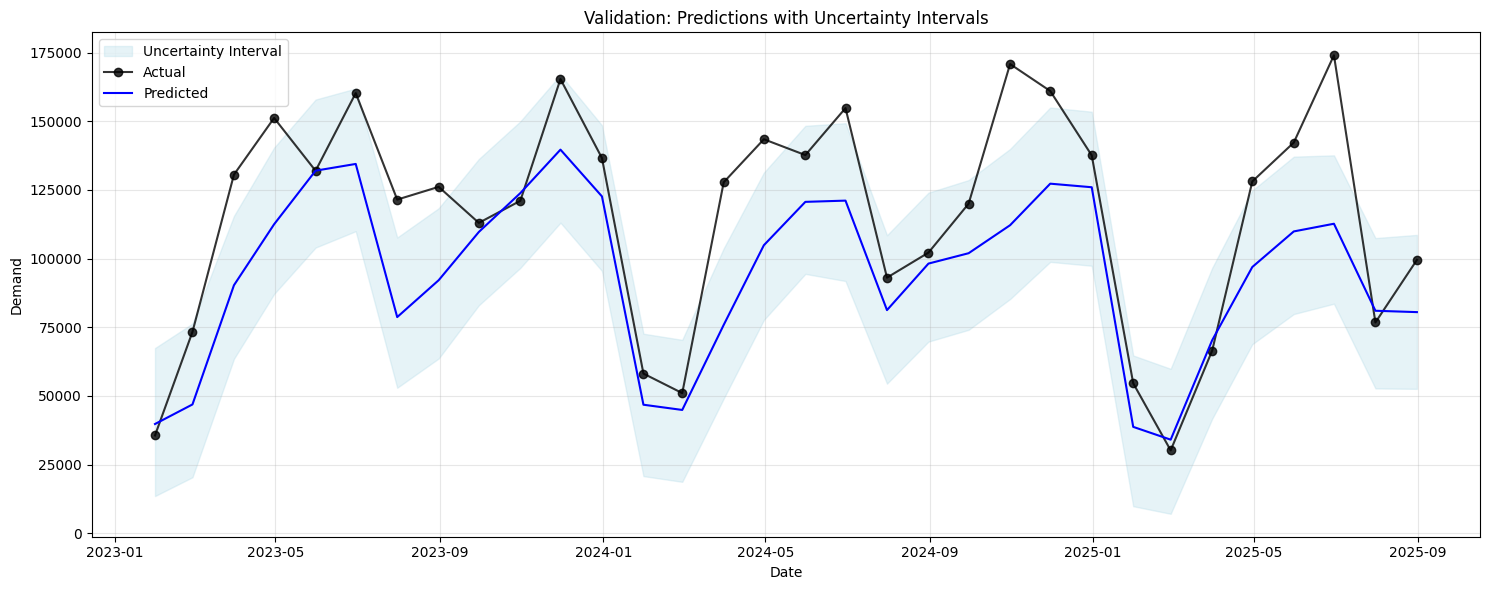


📊 Uncertainty Interval Coverage: 62.5%
- Ideally should be close to 80% (Prophet's default interval_width=0.80)
- Much lower suggests model is OVERCONFIDENT
- Much higher suggests model is UNDERCONFIDENT


In [32]:
# 8.3 Prediction Uncertainty Intervals
# Prophet provides uncertainty estimates - check if they're reasonable

fig, ax = plt.subplots(figsize=(15, 6))

# Plot validation data with uncertainty
ax.fill_between(valid_forecast['ds'], 
                 valid_forecast['yhat_lower'], 
                 valid_forecast['yhat_upper'], 
                 alpha=0.3, color='lightblue', label='Uncertainty Interval')
ax.plot(viz_valid['ds'], viz_valid['y'], 'o-', label='Actual', color='black', alpha=0.8)
ax.plot(valid_forecast['ds'], valid_forecast['yhat'], '-', label='Predicted', color='blue')
ax.set_xlabel('Date')
ax.set_ylabel('Demand')
ax.set_title('Validation: Predictions with Uncertainty Intervals')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate coverage
in_interval = ((df_valid['y'].values >= valid_forecast['yhat_lower'].values) & 
               (df_valid['y'].values <= valid_forecast['yhat_upper'].values))
coverage = in_interval.mean() * 100

print(f"\n📊 Uncertainty Interval Coverage: {coverage:.1f}%")
print("- Ideally should be close to 80% (Prophet's default interval_width=0.80)")
print("- Much lower suggests model is OVERCONFIDENT")
print("- Much higher suggests model is UNDERCONFIDENT")

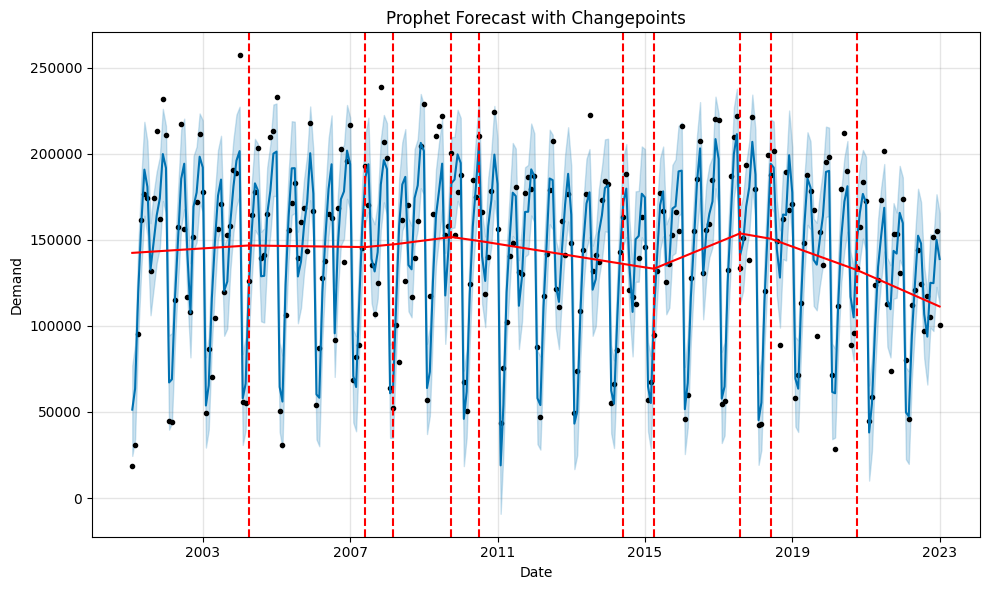


📊 Changepoint Analysis Guidelines:
- Red dashed lines show detected CHANGEPOINTS (trend changes)
- Check if changepoints align with known events (product changes, market shifts)
- If trend changes are MISSED, increase changepoint_prior_scale
- If too NOISY/overfitting, decrease changepoint_prior_scale

Current changepoint_prior_scale: 0.5


In [33]:
# 8.2 Changepoint Detection Visualization
# Visualize where the model detected trend changes

from prophet.plot import add_changepoints_to_plot

fig = model.plot(train_forecast)
a = add_changepoints_to_plot(fig.gca(), model, train_forecast)
plt.title('Prophet Forecast with Changepoints')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.tight_layout()
plt.show()

print("\n📊 Changepoint Analysis Guidelines:")
print("- Red dashed lines show detected CHANGEPOINTS (trend changes)")
print("- Check if changepoints align with known events (product changes, market shifts)")
print("- If trend changes are MISSED, increase changepoint_prior_scale")
print("- If too NOISY/overfitting, decrease changepoint_prior_scale")
print(f"\nCurrent changepoint_prior_scale: {best_params['changepoint_prior_scale']}")

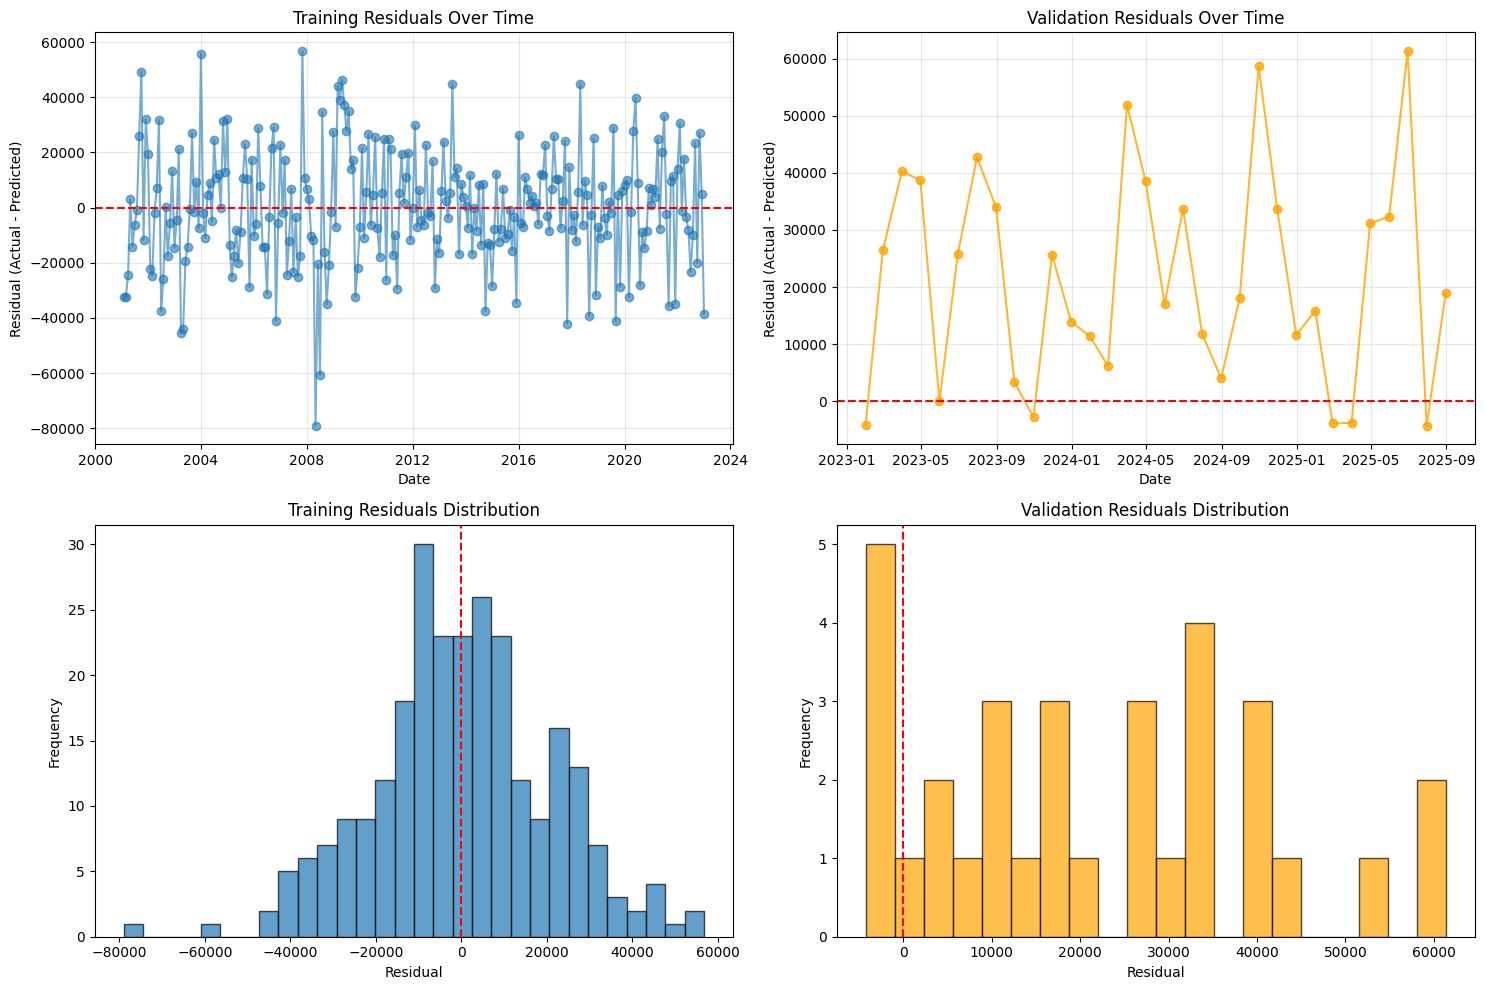


📊 Residual Analysis Guidelines:
- Look for PATTERNS in residuals over time (systematic under/over-prediction)
- Check if residuals are roughly CENTERED around zero
- Large residuals at specific dates may indicate MISSED CHANGEPOINTS
- Seasonal patterns in residuals suggest SEASONALITY_PRIOR_SCALE needs adjustment


In [34]:
# 8.1 Residual Analysis - Look for patterns in errors
residuals_train = df_train['y'].values - train_pred
residuals_valid = df_valid['y'].values - valid_pred

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Residuals over time (training)
axes[0, 0].plot(viz_train['ds'], residuals_train, 'o-', alpha=0.6)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_title('Training Residuals Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Residual (Actual - Predicted)')
axes[0, 0].grid(True, alpha=0.3)

# Residuals over time (validation)
axes[0, 1].plot(viz_valid['ds'], residuals_valid, 'o-', alpha=0.8, color='orange')
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_title('Validation Residuals Over Time')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Residual (Actual - Predicted)')
axes[0, 1].grid(True, alpha=0.3)

# Residual histogram (training)
axes[1, 0].hist(residuals_train, bins=30, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, color='r', linestyle='--')
axes[1, 0].set_title('Training Residuals Distribution')
axes[1, 0].set_xlabel('Residual')
axes[1, 0].set_ylabel('Frequency')

# Residual histogram (validation)
axes[1, 1].hist(residuals_valid, bins=20, alpha=0.7, edgecolor='black', color='orange')
axes[1, 1].axvline(x=0, color='r', linestyle='--')
axes[1, 1].set_title('Validation Residuals Distribution')
axes[1, 1].set_xlabel('Residual')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\n📊 Residual Analysis Guidelines:")
print("- Look for PATTERNS in residuals over time (systematic under/over-prediction)")
print("- Check if residuals are roughly CENTERED around zero")
print("- Large residuals at specific dates may indicate MISSED CHANGEPOINTS")
print("- Seasonal patterns in residuals suggest SEASONALITY_PRIOR_SCALE needs adjustment")

### 8. Visual Inspection Tools (Analyst-in-the-Loop)

This section provides tools for **visual inspection and manual refinement** of the model, following Prophet's "analyst-in-the-loop" philosophy. Use these visualizations to identify issues that metrics alone might miss.

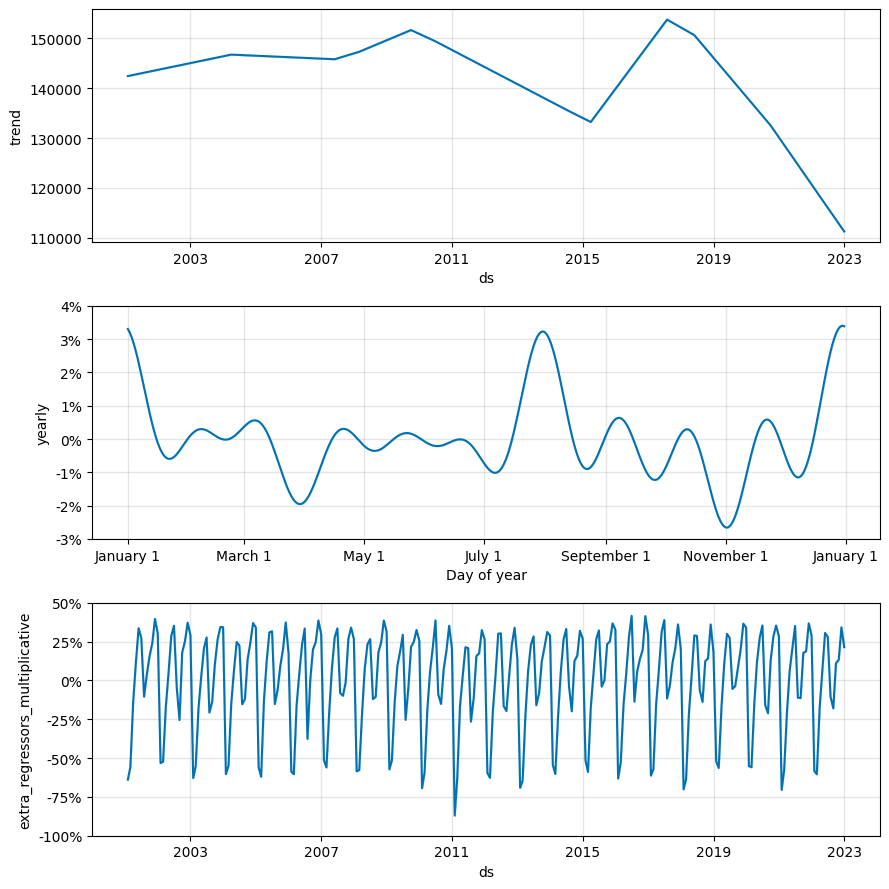

In [35]:
fig = model.plot_components(train_forecast)
plt.tight_layout()
plt.show()

### 7. Prophet Components Analysis